In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")

In [11]:
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

def multiply(a, b):
    '''
    Multiply Two number and return theutput
    '''

    return a * b

llm_bind = llm.bind_tools([multiply])

In [12]:
def tool_call_llm(state: MessagesState):
    return {"messages": llm_bind.invoke(state['messages'])}

In [13]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(MessagesState)

graph.add_node("llm_call", tool_call_llm)
graph.add_node("tools", ToolNode([multiply]))

graph.add_edge(START, "llm_call")
graph.add_conditional_edges("llm_call",tools_condition)
graph.add_edge("tools",END)

In [14]:
wf = graph.compile()

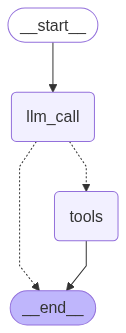

In [15]:
wf

In [16]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content = "Product of 2 and 3 is")]
final_response = wf.invoke({"messages":messages})

In [17]:
final_response

{'messages': [HumanMessage(content='Product of 2 and 3 is', additional_kwargs={}, response_metadata={}, id='03b8c799-08f0-452b-9b06-9c9c6f321c80'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2.0, "b": 3.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--682f76ac-75d9-4d47-92f6-ef24ef517925-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2.0, 'b': 3.0}, 'id': '6061dc0f-7b73-430b-bebc-e75cff1c4469', 'type': 'tool_call'}], usage_metadata={'input_tokens': 22, 'output_tokens': 5, 'total_tokens': 27, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='6.0', name='multiply', id='69dca0ad-1f06-4475-a869-2c77a057b875', tool_call_id='6061dc0f-7b73-430b-bebc-e75cff1c4469')]}

In [21]:
from pprint import pprint
for m in final_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Product of 2 and 3 is
================================== Ai Message ==================================
Tool Calls:
  multiply (6061dc0f-7b73-430b-bebc-e75cff1c4469)
 Call ID: 6061dc0f-7b73-430b-bebc-e75cff1c4469
  Args:
    a: 2.0
    b: 3.0
================================= Tool Message =================================
Name: multiply

6.0
